In [36]:
import pandas as pd
import sqlite3
import os
from pathlib import Path
import numpy as np
import seaborn as sns
import peewee as pw
import matplotlib.pyplot as plt
import sklearn as skl

#swithc working directory to 
os.chdir(r'c:\Repositories\asphalt-db')
from main.data_classifications import *
from main.data_processing import *
from src.db_builder.models import *
from main.query_database import *
from main.heterogeneity_regression import fit_linear_regression

sns.set_style('whitegrid')
working_dir = Path(r'c:\Repositories\asphalt-db\results')
results_dir = Path(r'c:\Users\klerk_wj\OneDrive - Stichting Deltares\00_Projecten\09_Kvk Asfalt\results')

In [37]:
# Read into a pandas DataFrame
dikes_and_projects = query_dikes_and_projects(sqlite3.connect(working_dir.parent.joinpath('data','database_all_v5.sqlite')))
df_final = load_and_merge_data(working_dir.parent.joinpath('data','database_all_v5.sqlite'))
data_per_dike_project = get_section_based_statistics(df_final, dikes_and_projects)
df_final, data_per_dike_project = classifications_wrapper(df_final, data_per_dike_project)


In [39]:
data_per_dike_project['target'] = data_per_dike_project['sig_b_mean']
dike_project_for_linear_regression = data_per_dike_project.copy()
#reanme sig_b_mean to sig_b
dike_project_for_linear_regression = dike_project_for_linear_regression.rename(columns={'sig_b_mean':'sig_b'})
fit_linear_regression(dike_project_for_linear_regression, use_HR_as_regressor=False, heterogeneity_category='Homogeen')

{'heterogeneity_category': 'Homogeen',
 'beta': array([ 9.42282378, -0.082522  ]),
 'se': np.float64(1.0208305730430838),
 'beta_ste': array([0.3104516 , 0.01027667]),
 'beta_cov': array([[ 8.50236681e-02, -2.06552473e-03],
        [-2.06552473e-03,  7.12407587e-05]]),
 't_values': array([30.35198978, -8.03003253]),
 'p_values': array([3.04575411e-27, 1.53753989e-09]),
 'conf_int': array([[ 8.79319875, 10.0524488 ],
        [-0.10336405, -0.06167994]]),
 'r_2': np.float64(0.6417248170036953),
 'X_training': array([22, 32, 29, 19, 29, 19, 29, 30, 39, 35, 34, 35, 44, 12, 38, 43,  0,
         0,  0,  0,  0, 49, 18, 31, 34, 34, 31, 55, 31, 31, 41, 36,  0, 28,
         0, 53,  5,  5]),
 'X_all': array([22, 48, 32, 32, 34, 44, 33, 29, 39, 29, 41, 19, 28, 29, 19, 29, 32,
        41, 30, 22, 39, 43, 54, 56, 39, 39, 44, 40, 41, 35, 46, 35, 34, 34,
        43, 35, 58, 61, 49, 44, 38, 12, 37, 38, 43, 47, 42, 51,  0,  0,  0,
         0,  0,  0, 49, 49, 49, 56, 50, 50, 50, 35, 18, 31, 34, 34, 34, 3

In [34]:
df_final.shape

(752, 44)

<Axes: xlabel='age_at_investigation', ylabel='sig_b_cov'>

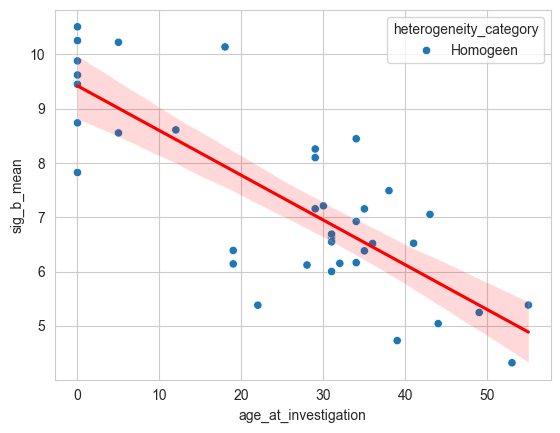

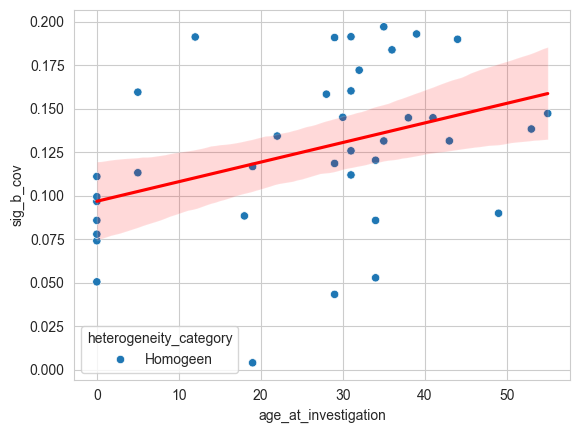

In [3]:
subset = data_per_dike_project.loc[data_per_dike_project['heterogeneity_category'].isin(['Homogeen'])]
sns.scatterplot(data=subset, x = 'age_at_investigation', y = 'sig_b_mean', hue = 'heterogeneity_category')
sns.regplot(data=subset, x = 'age_at_investigation', y = 'sig_b_mean', scatter_kws={'s':5}, line_kws={'color':'red'})
plt.figure()
sns.scatterplot(data=subset, x = 'age_at_investigation', y = 'sig_b_cov', hue = 'heterogeneity_category')
sns.regplot(data=subset, x = 'age_at_investigation', y = 'sig_b_cov', scatter_kws={'s':5}, line_kws={'color':'red'})

In [ ]:
subset["target"] = subset["sig_b_mean"]
subset.rename(columns={"HR_mean": "HR"}, inplace=True)
#use relative dike_data for regression
#do a regression with sklearn to get slope and intercept of sig_b vs age_at_investigation
results = fit_linear_regression(subset,use_HR_as_regressor=False)

C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_29748\4261581987.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["target"] = subset["sig_b_mean"]
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_29748\4261581987.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset.rename(columns={"HR_mean": "HR"}, inplace=True)


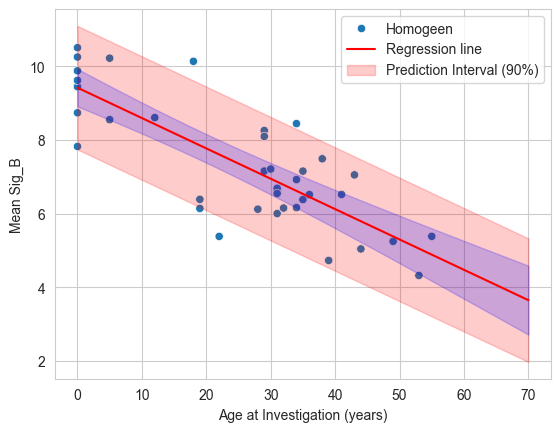

In [ ]:
def get_ci_from_regression(results,x_grid):
    intercept, slope = results['beta']
    se_intercept, se_slope = results['beta_ste']
    cov_matrix = results['beta_cov']
    
    #confidence interval for the regression line
    ci_lower = intercept + slope * x_grid - 1.645 * np.sqrt(
        se_intercept**2 + (x_grid**2) * se_slope**2 + 2 * x_grid * cov_matrix[0, 1]
    )
    ci_upper = intercept + slope * x_grid + 1.645 * np.sqrt(
        se_intercept**2 + (x_grid**2) * se_slope**2 + 2 * x_grid * cov_matrix[0, 1]
    )
    return ci_lower, ci_upper

intercept, slope = results['beta']
se_intercept, se_slope = results['beta_ste']
#covariance matrix
cov_matrix = results['beta_cov']

standard_error = results['se']
x_grid = np.linspace(0,70,70)
#plot mean
fig,ax = plt.subplots()
sns.scatterplot(data=subset, x = 'age_at_investigation', y = 'sig_b_mean', hue = 'heterogeneity_category', ax=ax)
ax.plot(x_grid, intercept + slope * x_grid, color='red', label='Regression line')
#prediction interval
pi_lower = intercept + slope * x_grid - 1.645 * standard_error
pi_upper = intercept + slope * x_grid + 1.645 * standard_error
ax.fill_between(x_grid, pi_lower, pi_upper, color='red', alpha=0.2, label='Prediction Interval (90%)')
ax.set_xlabel('Age at Investigation (years)')
ax.set_ylabel('Mean Sig_B')
ax.legend()

#confidence interval for the regression line
ci_lower = intercept + slope * x_grid - 1.645 * np.sqrt(
    se_intercept**2 + (x_grid**2) * se_slope**2 + 2 * x_grid * cov_matrix[0, 1]
)
ci_upper = intercept + slope * x_grid + 1.645 * np.sqrt(
    se_intercept**2 + (x_grid**2) * se_slope**2 + 2 * x_grid * cov_matrix[0, 1]
)
ax.fill_between(x_grid, ci_lower, ci_upper, color='blue', alpha=0.2, label='Confidence Interval (95%)') 


<Axes: xlabel='age_at_investigation', ylabel='sig_b_mean'>

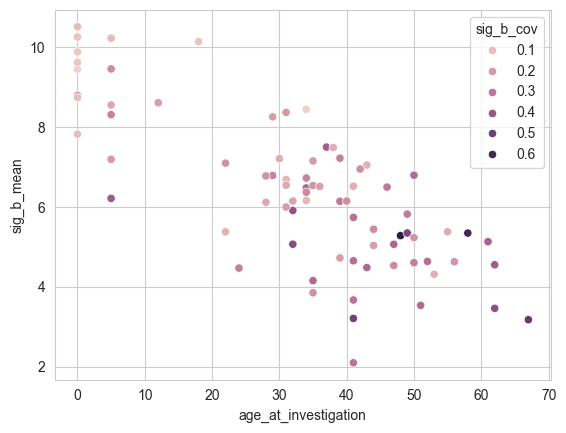

In [31]:
sns.scatterplot(data=data_per_dike_project.loc[data_per_dike_project.number_of_boreholes_count > 6], x = 'age_at_investigation', y = 'sig_b_mean', hue = 'sig_b_cov')

In [29]:
data_per_dike_project.loc[data_per_dike_project.HR_mean > 12].sig_b_cov

29    0.335005
Name: sig_b_cov, dtype: float64